# Price Analysis
# 価格分析

This section examines how grape prices vary across the dataset,
building on the structural differences identified in the previous analysis.

In the feature analysis, differences between variety groups were observed
in both physical characteristics and year of introduction.
However, these differences were not sufficient to fully distinguish the groups,
due to substantial variability within each category.

In this section, we focus on price as the outcome variable,
and explore how it relates to variety groups and observable features.

The analysis aims to identify whether the structural differences
observed earlier are reflected in price variation.

本セクションでは、前節で確認された構造的な違いを踏まえ、
ぶどう価格の変動について分析を行います。

特徴量分析では、外観特性および導入年において
品種グループ間の違いが確認されましたが、
各グループ内のばらつきも大きく、
それだけで完全に区別できるものではありませんでした。

本分析では、価格を目的変数として扱い、
品種グループおよび観測可能な特徴量との関係を検討します。

前節で見られた構造的な違いが、
価格の差としてどのように現れるかを明らかにすることを目的とします。

In [ ]:
import pandas as pd

df = pd.read_csv("grape_data_cleaned.csv")

### Price Distribution/価格分布

Prices exhibit a right-skewed distribution,
with a small number of high-priced products.

価格分布は右に裾の長い形状を示し、
少数の高価格商品が存在します。

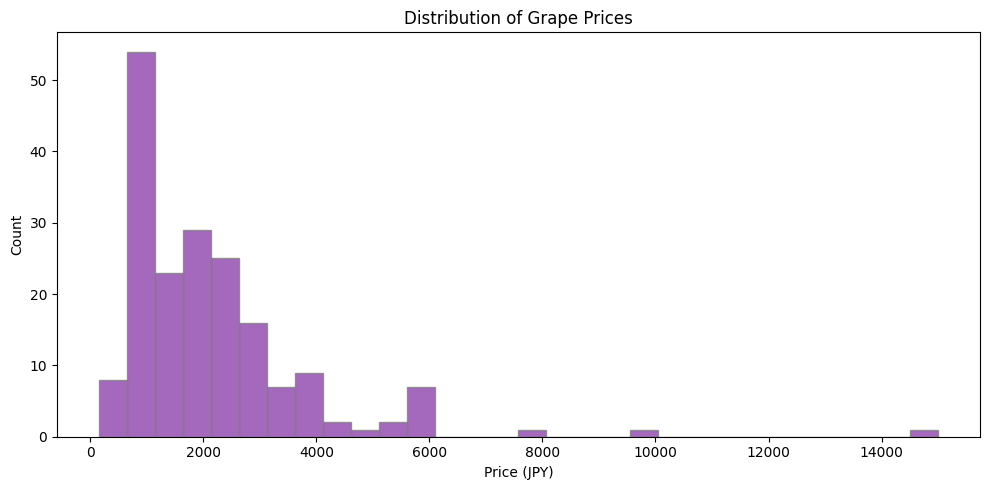

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df["price_yen_with_tax"],
    bins=30,
    color="#8E44AD",
    edgecolor="grey",
    alpha=0.8
)

plt.xlabel("Price (JPY)")
plt.ylabel("Count")
plt.title("Distribution of Grape Prices")

plt.tight_layout()
plt.show()

### Average Price by Variety System/品種系統ごとの平均価格

This chart compares the average retail price of
Shine Muscat-type and Kyoho-type grapes in the dataset.

この図は、データセットにおける
シャインマスカット系と巨峰系の平均販売価格を比較しています。

In [ ]:
GREEN = "#4CAF50"
PURPLE = "#8E44AD"

green_list = [
    'Queen Seven', 'Haneou', 'Queen Rouge', 'Shine Muscat',
    'Fujinokagayaki', 'Seto Giants', 'Shigyoku', 'Shinku', 'Kaiji',
    'Queen Roug', 'Scarlet', 'Red Shine Muscat', 'Suiho',
    'Sunshine Red', 'Ving', 'Wasekaiji', 'Pizzutello Bianco',
    'Nouvelle Rose', 'Muscat Noir', 'Miwahime'
]

In [ ]:
df["group"] = df["grape_variety"].apply(
    lambda x: "Shine Muscat-type" if x in green_list else "Kyoho-type"
)

In [ ]:
group_avg = (
    df.groupby("group")["price_yen_with_tax"]
      .mean()
      .reset_index()
      .sort_values("price_yen_with_tax", ascending=False)
)

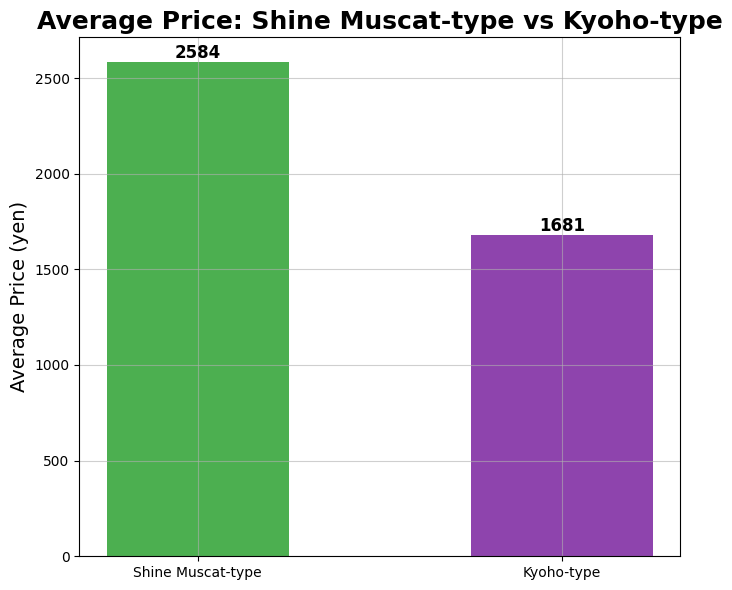

In [ ]:
color_map = {
    "Shine Muscat-type": GREEN,
    "Kyoho-type": PURPLE
}

plt.figure(figsize=(7,6))

bars = plt.bar(
    group_avg["group"],
    group_avg["price_yen_with_tax"],
    color=[color_map[g] for g in group_avg["group"]],
    width=0.5
)

for p in bars:
    height = p.get_height()
    plt.annotate(
        f"{height:.0f}",
        (p.get_x() + p.get_width()/2., height),
        ha="center", va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Average Price: Shine Muscat-type vs Kyoho-type", fontsize=18, fontweight="bold")
plt.ylabel("Average Price (yen)", fontsize=14)

plt.gca().grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

### Appearance Features vs Price/外観特性と価格の関係

The plots compare the relationship between price and two
appearance features: grain diameter and bunch length.

Both features show positive trends with price,
although the strength of the relationship appears to differ.

これらの図では、粒径と房の長さという2つの外観特性と
価格の関係を比較しています。

いずれの特性も価格との正の関係が見られるものの、
その関係の強さには違いがある可能性があります。



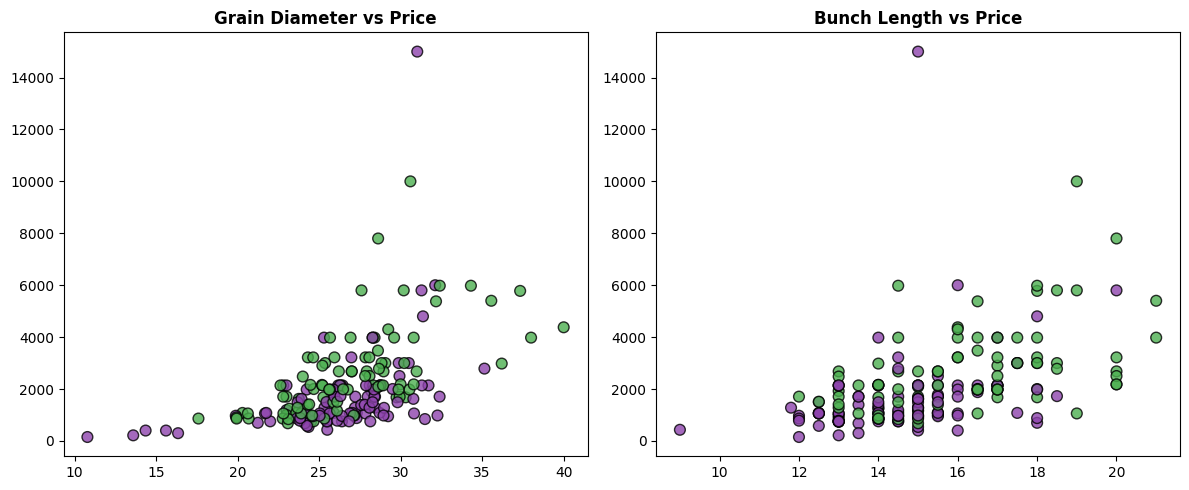

In [ ]:
import matplotlib.pyplot as plt

colors = df["group"].map(color_map)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(
    df["grain_diameter_mm"],
    df["price_yen_with_tax"],
    c=colors,
    s=60,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title("Grain Diameter vs Price",fontweight="bold")

axes[1].scatter(
    df["bunch_length_cm"],
    df["price_yen_with_tax"],
    c=colors,
    s=60,
    edgecolor="black",
    alpha=0.8
)

axes[1].set_title("Bunch Length vs Price",fontweight="bold")

plt.tight_layout()
plt.show()


### Year Introduced vs Price/品種導入年と価格の関係

The relationship between year introduced and price
appears to be weak, with substantial variation observed
within similar time periods.

導入年と価格の関係は明確ではなく、
同じ年代においても価格のばらつきが大きいことが確認されます。

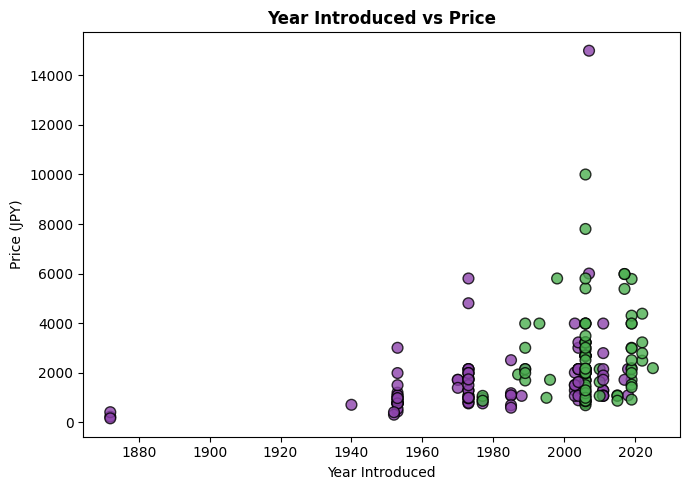

In [ ]:
colors = df["group"].map(color_map)

plt.figure(figsize=(7,5))

plt.scatter(
    df["year_introduced"],
    df["price_yen_with_tax"],
    c=colors,
    s=60,
    edgecolor="black",
    alpha=0.8
)

plt.xlabel("Year Introduced")
plt.ylabel("Price (JPY)")
plt.title("Year Introduced vs Price", fontweight="bold")

plt.tight_layout()
plt.show()

## Summary of Exploratory Analysis/探索的データ分析のまとめ

This exploratory analysis examined the relationship between
grape prices and several key factors, including variety system,
physical appearance, and year of introduction.

The price distribution shows a right-skewed pattern,
indicating the presence of a limited number of high-priced
products in the market.

Comparisons across variety systems suggest that
price levels may differ between Shine Muscat-type
and Kyoho-type grapes.

Analysis of appearance features indicates that
grain diameter exhibits a relatively clear relationship
with price, while bunch size shows a weaker and more
variable pattern.

The relationship between year of introduction and price
appears to be less pronounced, suggesting that factors
other than variety age may play a role in price formation.

Overall, these results indicate that both variety system
and observable physical characteristics are relevant
for understanding price differences in the dataset.

本分析では、ぶどう価格と品種系統、外観特性、
および導入年との関係について探索的に検討しました。

価格分布は右に裾の長い形状を示しており、
市場には一部の高価格商品が存在することが確認されました。

品種系統ごとの比較からは、
シャインマスカット系と巨峰系の間で
価格帯に違いが見られる可能性が示唆されます。

外観特性の分析では、粒径と価格の関係が比較的明確である一方、
房サイズはばらつきが大きく、
関係性はやや弱い傾向が確認されました。

また、導入年と価格の関係は明確ではなく、
価格形成には品種の新しさ以外の要因も
影響している可能性が考えられます。

以上より、本データセットにおける価格差の理解には、
品種系統と外観特性の両方が重要である可能性が示されました。

Additional exploratory figures were generated,
but only the most relevant results are shown in the main section.

追加の分析結果も作成していますが、
本編では主要な結果のみを掲載しています。